In [7]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (1).csv


In [8]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [12]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print(X.head())
print(y.head())

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               1        101348.88              False            False   
1               1        112542.58              False             True   
2               0        113931.57              False            False   
3               0         93826.63              False            False   
4               1         79084.10              False             True   

   Gender_Male  
0        False  
1        False  
2        False  
3        False  
4        False  
0    1
1    0
2    1
3    0
4    0
Name: Exi

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.811


**Random Forest**

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8665


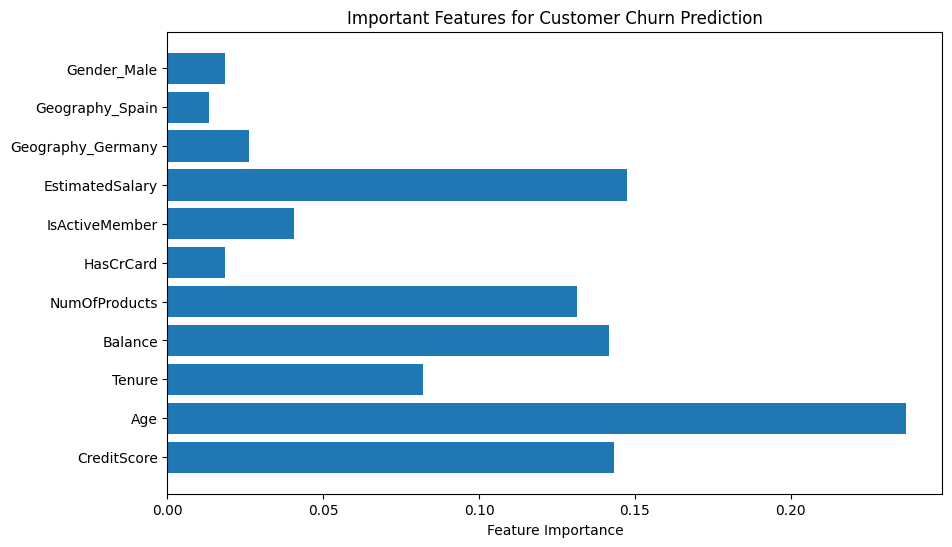

In [29]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Important Features for Customer Churn Prediction")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
from google.colab import files

files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

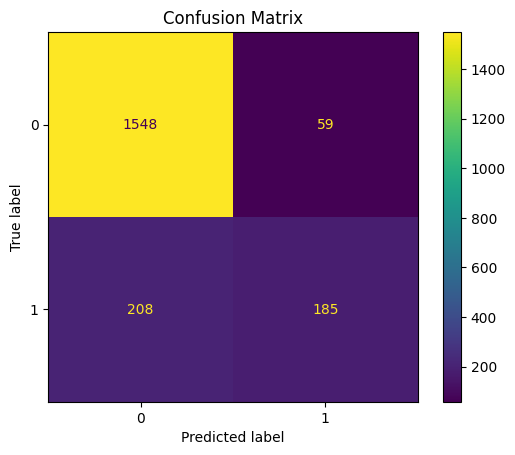

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
from google.colab import files

files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

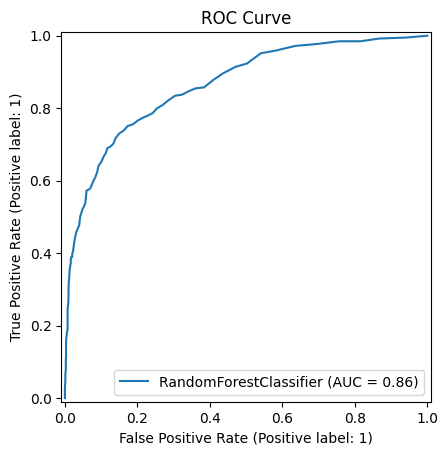

<Figure size 640x480 with 0 Axes>

In [28]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve")
plt.show()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

In [31]:
files.download("roc_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

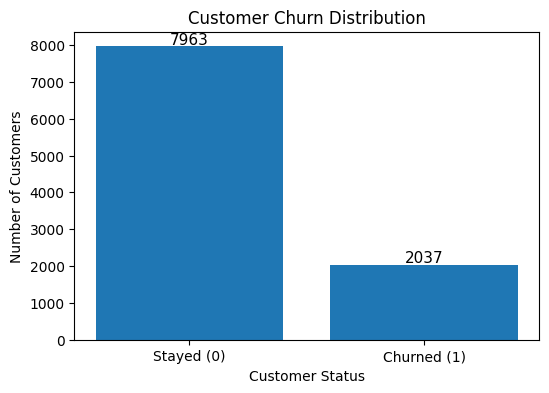

In [41]:
import matplotlib.pyplot as plt

# Count churn values
churn_counts = df['Exited'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Show count on top of bars
for i, count in enumerate(churn_counts.values):
    plt.text(i, count + 50, str(count), ha='center', fontsize=11)

# Save the graph
plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")

# Show the graph
plt.show()

In [42]:
from google.colab import files

files.download("churn_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

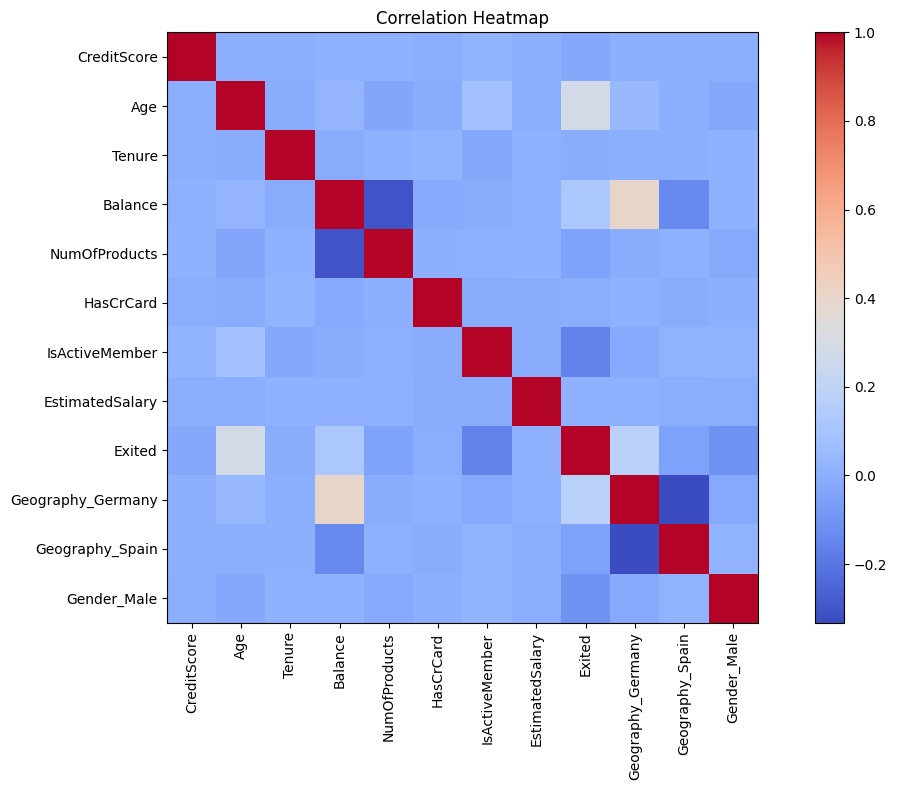

In [43]:
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save the graph
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

# Show the graph
plt.show()

In [44]:
from google.colab import files

files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

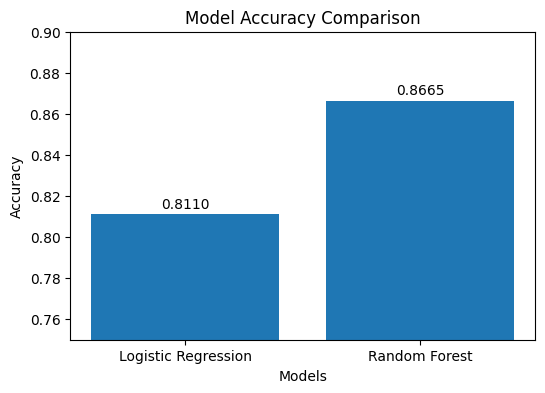

In [45]:
import matplotlib.pyplot as plt

# Model names and their accuracies
models = ['Logistic Regression', 'Random Forest']
accuracies = [0.811, 0.8665]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Display accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.003,
             f'{height:.4f}',
             ha='center')

plt.ylim(0.75, 0.90)

# Save the graph
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [46]:
from google.colab import files

files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import joblib

joblib.dump(rf, "customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [26]:
from google.colab import files

files.download("customer_churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>